<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Anomaly_detection_using_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn shap matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 1000
data = {
    "User_ID": np.random.choice(["U001", "U002", "U003", "U004", "U005"], size=n_samples),
    "IP_Address": np.random.choice(["192.168.1.2", "10.10.5.20", "203.0.113.5", "198.51.100.7"], size=n_samples),
    "Access_Level": np.random.choice(["Admin", "User", "Guest"], size=n_samples, p=[0.2, 0.6, 0.2]),
    "Accessed_Resource": np.random.choice(["Server_A", "Database_Y", "File_X", "File_Y"], size=n_samples),
    "Time_of_Access": np.random.randint(0, 24, size=n_samples),
    "Is_Anomalous": np.random.choice([0, 1], size=n_samples, p=[0.80, 0.20])  # 20% anomalies
}

df = pd.DataFrame(data)
df.to_csv("network_access_logs.csv", index=False)
print("Dataset saved as network_access_logs.csv")


Dataset saved as network_access_logs.csv


In [ ]:
from google.colab import files
files.download("network_access_logs.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load dataset
df = pd.read_csv("network_access_logs.csv")

# Convert categorical variables to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

encoders = {}  # Store encoders for later use

for col in ["User_ID", "IP_Address", "Access_Level", "Accessed_Resource"]:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])  # Fit and transform

# Separate features and target
X = df.drop(columns=["Is_Anomalous"])  # Features
y = df["Is_Anomalous"]  # Target

# Print preprocessed data
print(X.head())



   User_ID  IP_Address  Access_Level  Accessed_Resource  Time_of_Access
0        3           2             0                  0              22
1        4           2             0                  2               5
2        2           2             2                  1              21
3        4           2             2                  2              17
4        4           2             0                  2               5


In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest model
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X)

# Predict anomalies (-1 means anomaly, 1 means normal)
df["Predicted_Anomaly"] = model.predict(X)
df["Predicted_Anomaly"] = df["Predicted_Anomaly"].map({1: 0, -1: 1})  # Convert to binary (0 = normal, 1 = anomaly)

# Compare predictions with actual labels
print(df[["Is_Anomalous", "Predicted_Anomaly"]].head(10))



   Is_Anomalous  Predicted_Anomaly
0             0                  0
1             0                  0
2             0                  0
3             0                  0
4             0                  0
5             0                  0
6             1                  0
7             0                  0
8             0                  0
9             0                  0


<ipython-input-21-7b07fa18fe51>:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


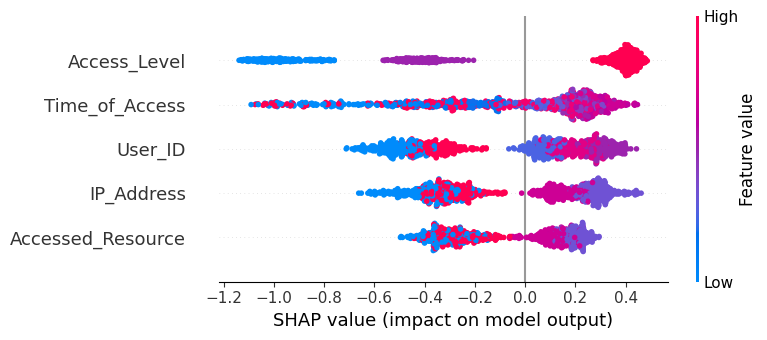

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Visualize feature importance
shap.summary_plot(shap_values, X)



In [ ]:
def encode_new_data(new_data, encoders):
    """Encode new categorical data safely, handling unseen labels."""
    encoded_data = {}
    for col, value in new_data.items():
        if col in encoders:
            if value in encoders[col].classes_:
                encoded_data[col] = encoders[col].transform([value])[0]
            else:
                encoded_data[col] = -1  # Assign an unknown label
        else:
            encoded_data[col] = value
    return encoded_data

# Example new access request
new_request = {
    "User_ID": "U007",  # Unseen user (not in training data)
    "IP_Address": "10.10.5.20",
    "Access_Level": "User",
    "Accessed_Resource": "Server_A",
    "Time_of_Access": 3  # Odd hours access
}

# Encode safely
encoded_request = encode_new_data(new_request, encoders)
new_request_df = pd.DataFrame([encoded_request])

# Predict if it's an anomaly
anomaly_prediction = model.predict(new_request_df)
is_anomalous = "Anomalous" if anomaly_prediction[0] == -1 else "Normal"

print(f"New Access Request: {new_request}")
print(f"Prediction: {is_anomalous}")



New Access Request: {'User_ID': 'U007', 'IP_Address': '10.10.5.20', 'Access_Level': 'User', 'Accessed_Resource': 'Server_A', 'Time_of_Access': 3}
Prediction: Normal


In [ ]:
def handle_anomaly(user_id):
    print(f"⚠ ALERT: User {user_id} is performing suspicious activity! Access restricted.")

# Apply automated response
df.apply(lambda row: handle_anomaly(row["User_ID"]) if row["Predicted_Anomaly"] == 1 else None, axis=1)


⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 2 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 3 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 1 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 4 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 0 is performing suspicious activity! Access restricted.
⚠ ALERT: User 4 is p

,0
0,None
1,None
2,None
3,None
4,None
...,...
995,None
996,None
997,None
998,None


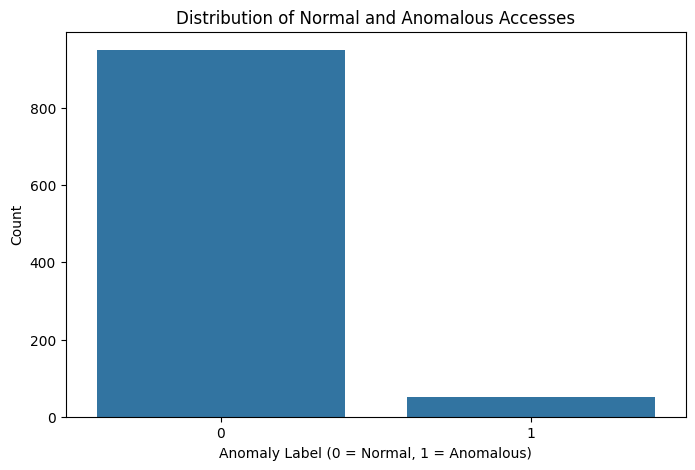

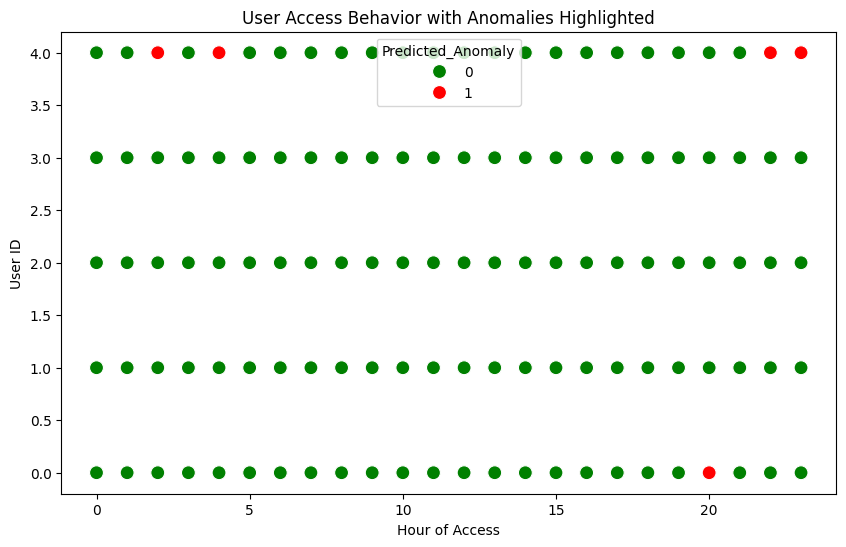

In [ ]:
import seaborn as sns

# Visualize anomaly distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Predicted_Anomaly"])
plt.title("Distribution of Normal and Anomalous Accesses")
plt.xlabel("Anomaly Label (0 = Normal, 1 = Anomalous)")
plt.ylabel("Count")
plt.show()

# Visualizing Access Time vs. Anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Time_of_Access"], y=df["User_ID"], hue=df["Predicted_Anomaly"], palette={0: 'green', 1: 'red'}, s=100)
plt.xlabel("Hour of Access")
plt.ylabel("User ID")
plt.title("User Access Behavior with Anomalies Highlighted")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Example: Replace with your actual values
y_true = [0, 1, 0, 1, 1, 0, 1, 0]  # Ground truth labels
y_pred = [0, 1, 0, 0, 1, 0, 1, 1]  # Model predictions

# Compute accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 75.00%
